# 🔍 Data Exploration – Project Panopticon
**EduGuard AI**

We explore the synthetic telemetry data after loading and before feature engineering.
We check for missing values, distributions, and correlations.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data.pipeline import build_full_pipeline

%matplotlib inline
sns.set_theme(style='whitegrid')

In [15]:
import sys
import os

# Add the project root to Python's path
project_root = os.path.abspath('..')  # go up one level to the project root
if project_root not in sys.path:
    sys.path.insert(0, project_root)
print("Project root:", project_root)

Project root: c:\My projects\project_panopticon


In [16]:
df_raw = build_full_pipeline(
    '../data/synthetic/video_telemetry.csv',
    '../data/synthetic/audio_telemetry.csv',
    '../data/synthetic/system_events.csv',
    '../data/synthetic/labels.csv'
)

In [17]:
# Check missing values
missing = df_raw.isnull().sum()
missing[missing > 0]

tab_switch    50
dtype: int64

In [18]:
# Summary statistics
df_raw.describe()

,timestamp,eye_gaze_angle,head_pose_x,head_pose_y,face_detected,audio_db,copy_paste,tab_switch,tab_switches,is_cheating,...,audio_rolling_std_30s,gaze_ema_5,audio_ema_5,gaze_ema_10,audio_ema_10,gaze_ema_20,audio_ema_20,tab_switch_density,copy_paste_density,cumulative_risk_score
count,600,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,550.000000,600.0,600.000000,...,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.0,600.000000,600.000000
mean,2026-06-26 09:30:19.500000,-0.536566,1.221697,0.528050,0.853333,45.993806,0.905000,0.465455,0.0,0.050000,...,3.698844,-0.526253,45.982699,-0.514476,45.970587,-0.494552,45.947437,0.0,9.050000,80.200000
min,2026-06-26 09:25:20,-31.045758,-8.688766,-8.764051,0.000000,40.000116,0.000000,0.000000,0.0,0.000000,...,0.000000,-18.946162,41.489651,-13.154627,41.697191,-8.033088,41.815785,0.0,0.000000,0.000000
25%,2026-06-26 09:27:49.750000,-4.207449,-1.568580,-2.044242,1.000000,42.774694,0.000000,0.000000,0.0,0.000000,...,2.816013,-1.961611,44.212188,-1.456818,44.499470,-1.146714,44.739245,0.0,0.000000,0.000000
50%,2026-06-26 09:30:19.500000,0.063986,0.598776,0.372644,1.000000,45.207330,1.000000,0.000000,0.0,0.000000,...,2.986999,-0.296072,45.232438,-0.266496,45.225845,-0.300695,45.237107,0.0,6.000000,115.500000
75%,2026-06-26 09:32:49.250000,2.424171,3.358839,2.167144,1.000000,47.927321,2.000000,1.000000,0.0,0.000000,...,3.206416,0.861117,46.221897,0.573923,45.948777,0.459219,45.786082,0.0,20.000000,150.000000
max,2026-06-26 09:35:19,27.606992,19.201086,19.456939,1.000000,73.096572,2.000000,3.000000,0.0,1.000000,...,10.437296,13.438687,65.822866,7.543927,64.314558,2.820619,62.441170,0.0,20.000000,194.000000
std,NaN,6.548677,4.159763,3.613115,0.354068,5.037079,0.933145,0.567556,0.0,0.218127,...,1.808259,2.972537,3.869464,2.180294,3.537362,1.641111,3.109745,0.0,9.147146,73.233316


Cheating distribution:
 is_cheating
0    570
1     30
Name: count, dtype: int64


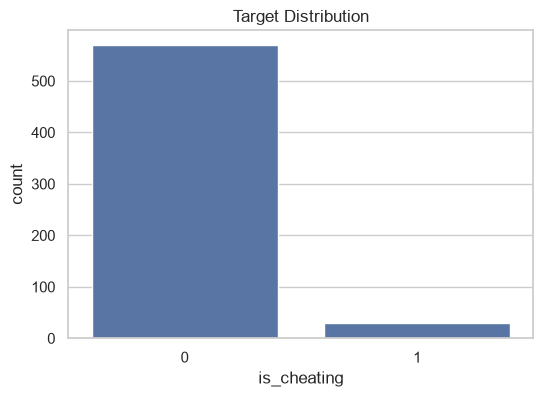

In [19]:
# Class distribution
print("Cheating distribution:\n", df_raw['is_cheating'].value_counts())
plt.figure(figsize=(6,4))
sns.countplot(x='is_cheating', data=df_raw)
plt.title('Target Distribution')
plt.show()

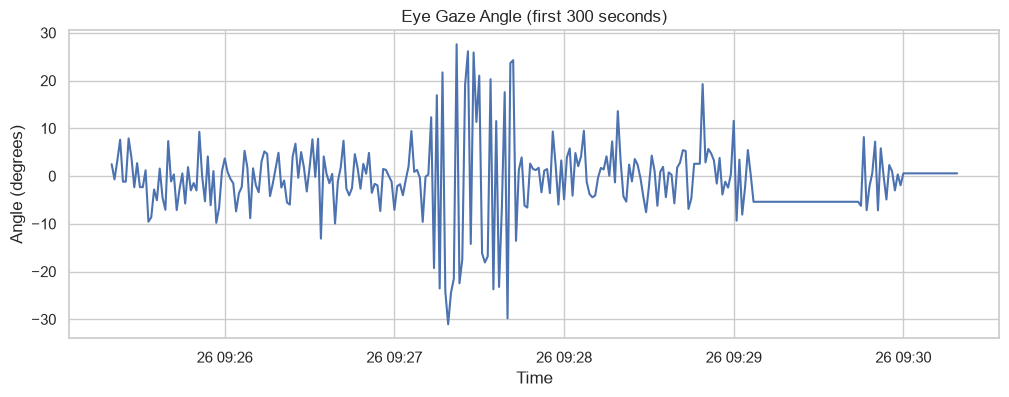

In [20]:
# Gaze angle over time (sample)
plt.figure(figsize=(12,4))
plt.plot(df_raw['timestamp'][:300], df_raw['eye_gaze_angle'][:300])
plt.title('Eye Gaze Angle (first 300 seconds)')
plt.xlabel('Time')
plt.ylabel('Angle (degrees)')
plt.show()

Constant columns dropped: ['tab_switches', 'tab_switch_density']


C:\Users\vasud\AppData\Local\Temp\ipykernel_24668\1081841966.py:25: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
c:\My projects\project_panopticon\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


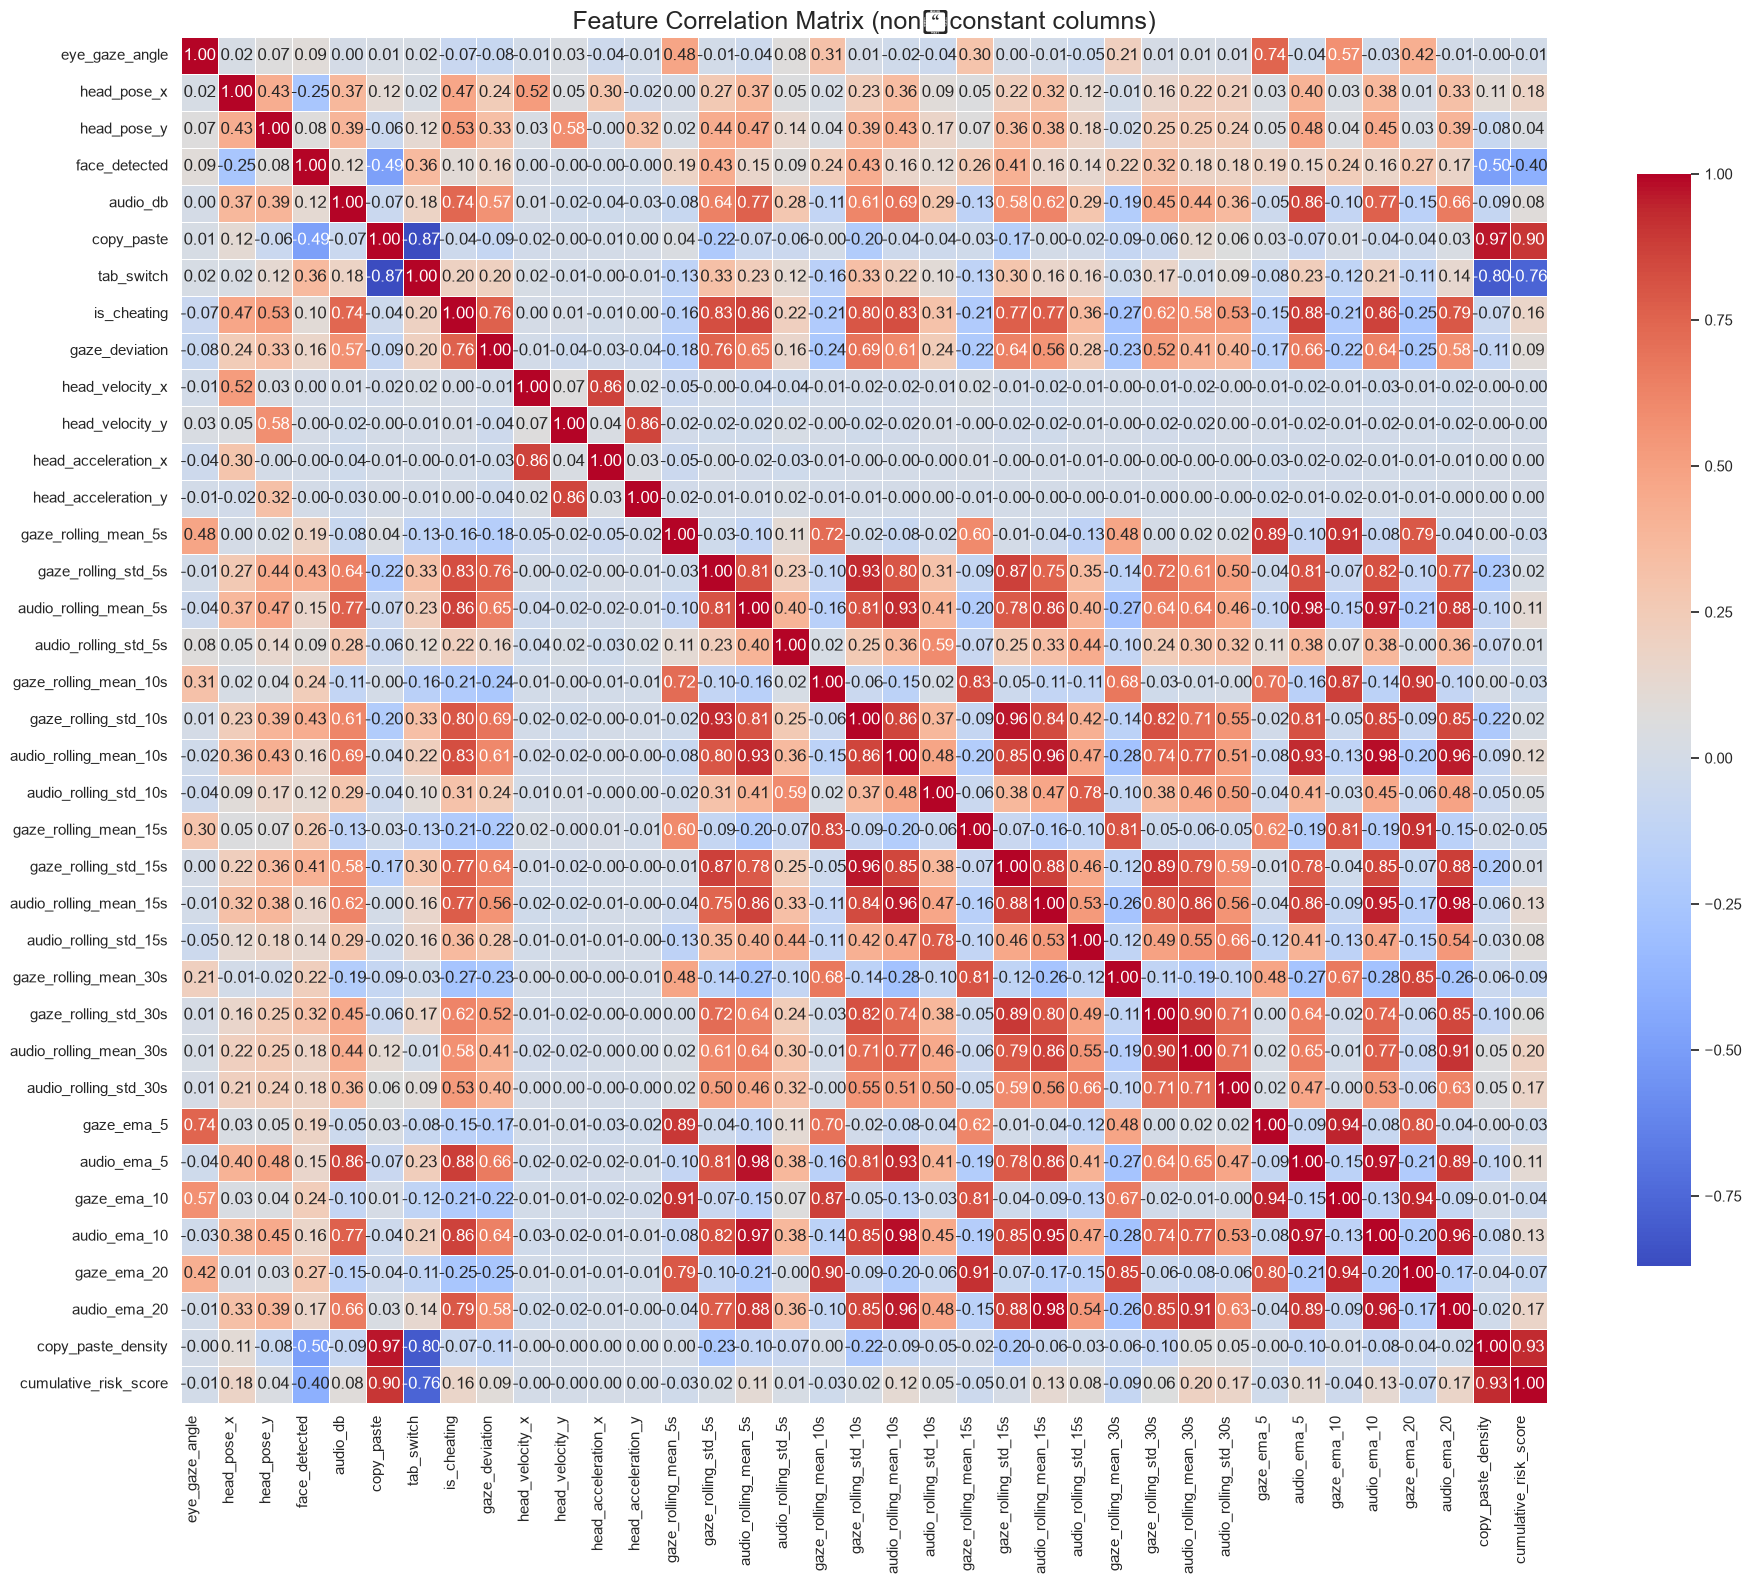

In [24]:
# Filter out constant columns (std == 0)
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns
constant_cols = [col for col in numeric_cols if df_raw[col].std() == 0]
print("Constant columns dropped:", constant_cols)
numeric_cols = [col for col in numeric_cols if col not in constant_cols]

# Compute correlation matrix
corr = df_raw[numeric_cols].corr()

# Plot a clear heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 16))  # larger figure
sns.heatmap(corr, 
            annot=True, 
            cmap='coolwarm', 
            fmt='.2f',
            linewidths=0.5,
            cbar_kws={"shrink": 0.8},
            square=True)  # makes cells square
plt.title('Feature Correlation Matrix (non‑constant columns)', fontsize=18)
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Key observations:**
- The target is highly imbalanced (≈5% cheating).
- Missing values are already handled by the pipeline (forward‑fill and interpolation).
- Gaze deviation and event frequencies are correlated with cheating labels.
- Rolling features (added later) will further smooth noise.